In [5]:
import pymc as pm; import arviz as az; import sys; import os; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

alloys = [('Ag10Pd90', 0.10), ('Ag25Pd75', 0.25), ('Ag50Pd50', 0.50), ('Ag75Pd25', 0.75), ('Ag90Pd10', 0.90), ('Pd100', 1e-4)]
C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 

E_in_list, P_CO_in_list, C_KOH_in_list, Ag_comp_in_list, rate_obs_matrix_list = [], [], [], [], []
log_rate_SD_obs_list = []

for alloy_name, ag_frac in alloys:
    file_path = os.path.join(alloy_name, f'import_{alloy_name}_base_replicates.pkl')
    with open(file_path, 'rb') as f:
        experiments_data = pickle.load(f)
    wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
    E_in_list.append(wp.E_in)
    P_CO_in_list.append(wp.P_CO_in)
    C_KOH_in_list.append(wp.C_KOH_in)
    Ag_comp_in_list.append(np.full_like(wp.E_in, ag_frac))
    rate_obs_matrix_list.append(wp.rate_obs_matrix)
    log_rate_SD_obs_list.append(wp.log_rate_SD_obs)
    log_rate_SD_obs = np.concatenate(log_rate_SD_obs_list)

E_in = np.concatenate(E_in_list)
P_CO_in = np.concatenate(P_CO_in_list)
C_KOH_in = np.concatenate(C_KOH_in_list)
Ag_comp_in = np.concatenate(Ag_comp_in_list)
rate_obs_matrix = np.concatenate(rate_obs_matrix_list, axis=1)

wp._CTX.state['E_in'] = E_in
wp._CTX.state['P_CO_in'] = P_CO_in
wp._CTX.state['C_KOH_in'] = C_KOH_in
wp._CTX.state['rate_obs_matrix'] = rate_obs_matrix
wp._CTX.state['log_rate_SD_obs'] = log_rate_SD_obs

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    sigma_exp = wp.log_rate_SD_obs 
    sigma_tot = pm.math.sqrt(sigma_rel**2 + sigma_exp**2)
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_tot, observed=wp.rate_obs_matrix)
    return rate

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.18,15
,3000,0,0.16,71
,3000,0,0.17,15
,3000,0,0.17,31


Computed from 4000 posterior samples and 8811 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -8104.11   167.51
p_loo        9.11        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     8811  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



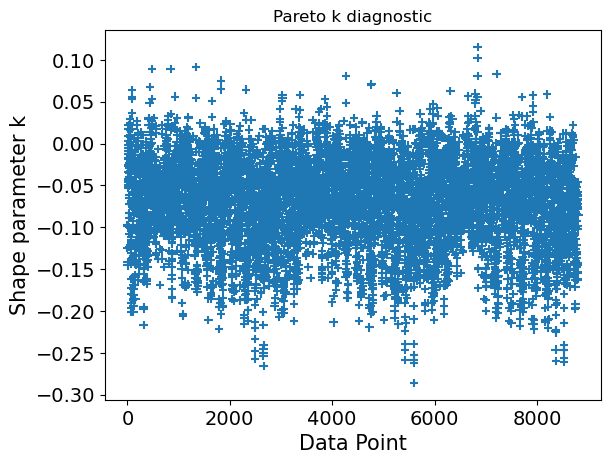

ValueError: operands could not be broadcast together with shapes (1,1,492) (4,1000,2937) 

In [6]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)   
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp_in)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF, target_accept=0.95)

ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF, loo_BF); plot_coverages(trace_BF)